
# AFM simulation and CNN



**This notebook provides you with a complete code example on how to create a simulated AFM dataset and how to train a regression model in order to do post-processing.**

In the first section, we simulate a dataset. The second section consists building and training a model.

- **Output1:** A simulated AFM dataset.
- **Output2:** A trained model ready to process experimental data.


## 1. Optional installations

Uncomment the lines you need in a fresh environment.


In [117]:
#!pip install deeplay plotly ipywidgets ipympl


## 2. Imports and configuration

The defaults below are chosen so the notebook stays light enough for experimentation.
If you want the number of points per curve to be derived from the physical scan settings,
set `simulation_config.n_points_per_phase = None`.


In [330]:
from __future__ import annotations

from dataclasses import dataclass, field
from pathlib import Path
from typing import Dict, Iterable, List, Literal, Optional, Tuple

import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset

torch.set_num_threads(1)

SEED = 72
np.random.seed(SEED)
torch.manual_seed(SEED)


@dataclass
class SimulationConfig:
    """Configuration for AFM curve simulation.

    Parameters
    ----------
    nx : int
        Number of pixels in the x direction.
    ny : int
        Number of pixels in the y direction.
    pixel_size_m : float
        Pixel size in meters.
    z_length_m : float
        Total piezo travel during approach or retract, in meters.
        The default is 10 µm, not 10^6 m.
    sampling_frequency_hz : float
        Sampling frequency for the force curve.
    approach_rate_um_s : float
        Approach rate in micrometers per second.
    n_points_per_phase : int or None
        Number of points for approach only. If None, it is computed from
        `z_length_m`, `approach_rate_um_s`, and `sampling_frequency_hz`.
    tip_shape : {"Sphere", "Pyramid"}
        Contact model geometry.
    include_thermal_noise : bool
        Whether to add thermal noise to deflection.
    noise_type : {"Equipartition", "Theoretical", "Experimental"}
        Either to use a PSD or not for noise generation and if we use PSD  the type of PSD we use.
    experimental_noise_path : str or None
        Optional path to a text file containing experimental PSD data.
    """

    nx = 32
    ny = 32
    pixel_size_m = 2e-6
    z_length_m = 10e-6
    sampling_frequency_hz = 2048
    approach_rate_um_s = 2.0
    n_points_per_phase = 512
    tip_shape = "Sphere"  # "Sphere" or "Pyramid"
    include_thermal_noise = True
    noise_type = "Experimental"  # "Theoretical" or "Experimental"
    experimental_noise_path = "thermal-noise-data_vDeflection_2025.11.28-16.29.33.tnd"


@dataclass
class DatasetConfig:
    """Configuration for synthetic sample-map generation."""

    n_train_samples = 18
    n_val_samples = 4
    n_test_samples = 3
    topography_types = ("gaussian_features", "hemisphere")
    substrate_stiffness_range_pa = (10e3, 20e3)
    feature_stiffness_range_pa = (1e3, 4e3)
    height_range_m = (0.1e-6, 0.6e-6)
    contact_point_offset_range_m = (0.25e-6, 5.0e-6)
    contact_point_jitter_m = 0.15e-6


@dataclass
class ModelConfig:
    """Configuration for the CNN regressor and training loop."""

    batch_size = 512
    learning_rate = 2e-3
    max_epochs = 12
    predict_contact_point = True
    cp_loss_weight = 0.1
    use_deeplay = True
    num_workers = 0


simulation_config = SimulationConfig()
dataset_config = DatasetConfig()
model_config = ModelConfig()

print(simulation_config)
print(dataset_config)
print(model_config)

SimulationConfig()
DatasetConfig()
ModelConfig()



## 3. Cantilever model with PSD




Here we define a class that represents our cantilever. The user must input the following information: tip geometry, tip size, spring constant, resonant frequency, quality factor and the temperature. These information can be found on the cantilever original box or in the thermal calibration file.

The cantilever class is responsible for defining the right contact area for a given indentation and defining the thermal noise in our system. We provide three options for thermal noise generation. One, we compute the mean square displacement of the cantilever from equipartition theorem. Second, we generate a power spectral density (PSD) of the cantilever which behaves as a damped harmonic oscillator in order to obtain a noise signal. Third, the user can upload the thermal calibration file of their cantilever to generate the noise signal. Please select the desired method and provide the necessary information to pursue.

In [347]:
Array = np.ndarray


class AFMCantilever:
    """AFM cantilever model with thermal-noise PSD support.

    Parameters
    ----------
    k : float
        Spring constant in N/m.
    f0 : float
        Resonance frequency in Hz.
    Q : float
        Quality factor.
    T : float
        Temperature in kelvin.
    """

    k: float
    f0: float
    Q: float
    T: float
    kB: float
    m_eff: float
    gamma: float
    _experimental_psd_cache: Dict[Tuple[str, float, float], Tuple[Array, Array, Array]]
    _grid_psd_cache: Dict[
        Tuple[str, int, float, Optional[str], float], Tuple[Array, Array]
    ]

    def __init__(
        self,
        k=10,
        f0=7e3,
        Q=10.0,
        T=300.0,
    ):
        self.k = k
        self.f0 = f0
        self.Q = Q
        self.T = T
        self.kB = 1.380649e-23
        self.m_eff = k / (2.0 * np.pi * f0) ** 2
        self.gamma = 2.0 * np.pi * f0 * self.m_eff / Q
        self._experimental_psd_cache = {}
        self._grid_psd_cache = {}

    def thermal_noise_rms(self):
        """Return the RMS thermal deflection in meters."""
        return np.sqrt(self.kB * self.T / self.k)

    def thermal_noise_psd_theoretical(self, frequency_hz):
        """Return the one-sided theoretical displacement PSD.

        Parameters
        ----------
        frequency_hz : ndarray
            Frequency axis in hertz.

        Returns
        -------
        ndarray
            One-sided displacement PSD in m^2/Hz.
        """
        omega = 2.0 * np.pi * frequency_hz
        omega0 = 2.0 * np.pi * self.f0
        denominator = (omega0**2 - omega**2) ** 2 + (omega * omega0 / self.Q) ** 2
        spectral_density_x = (4.0 * self.kB * self.T * self.gamma) / (
            self.k**2 * denominator
        )
        return spectral_density_x

    def thermal_noise_psd_experimental(self, path):
        """Load and cache an experimental displacement PSD.

        Parameters
        ----------
        path : str
            Path to the PSD text file.

        Returns
        -------
        tuple of ndarray
            Frequency axis in hertz and displacement PSD in m^2/Hz.
        """
        cache_key = str(path)
        if cache_key not in self._experimental_psd_cache:
            data = np.loadtxt(path, skiprows=24)
            frequency_hz = data[:, 0]
            spectral_density_v = data[:, 1]
            spectral_density_v_fit = data[:, 3]
            with open(path, "r") as f:
                lines = f.readlines()
            for line in lines:
                if "sensitivity" in line:
                    volts_to_displacement_nm = float(line.split(":")[1].split()[0])
                if "parameter.f" in line:
                    self.f0 = float(line.split(":")[1].split()[0])*1e3
                    print(self.f0)
                if "parameter.Q" in line:
                    self.Q = float(line.split(":")[1].split()[0])
                    print(self.Q)
            displacement_scale_m = volts_to_displacement_nm * 1e-9
            spectral_density_x = spectral_density_v * displacement_scale_m**2
            spectral_density_x_fit = spectral_density_v_fit * displacement_scale_m**2
            self._experimental_psd_cache[cache_key] = (frequency_hz, spectral_density_x, spectral_density_x_fit)
        return self._experimental_psd_cache[cache_key]

    def get_noise_psd(
        self,
        n_points,
        sampling_frequency_hz,
        noise_type=simulation_config.noise_type,  # "Theoretical" or "Experimental"
        experimental_path=simulation_config.experimental_noise_path,
    ):
        """Return the simulation-grid PSD, reusing cached results when possible."""
        cache_key = (
            noise_type.lower(),
            int(n_points),
            float(sampling_frequency_hz),
            None if experimental_path is None else str(experimental_path),
        )
        if cache_key in self._grid_psd_cache:
            return self._grid_psd_cache[cache_key]

        frequency_hz = np.fft.rfftfreq(n_points, d=1.0 / sampling_frequency_hz)
        if noise_type.lower() == "theoretical":
            spectral_density_x = self.thermal_noise_psd_theoretical(frequency_hz)
        elif noise_type.lower() == "experimental":
            if experimental_path is None:
                raise ValueError(
                    "`experimental_path` must be provided for experimental PSD noise."
                )
            frequency_raw_hz, spectral_density_raw, spectral_density_fit = (
                self.thermal_noise_psd_experimental(experimental_path)
            )
            interpolator = interp1d(
                frequency_raw_hz,
                spectral_density_raw,
                kind="linear",
                bounds_error=False,
                fill_value=(spectral_density_raw[0], spectral_density_raw[-1]),
            )
            spectral_density_x = interpolator(frequency_hz)
        else:
            raise ValueError(f"Unknown noise type: {noise_type}")

        self._grid_psd_cache[cache_key] = (frequency_raw_hz, spectral_density_raw)
        return self._grid_psd_cache[cache_key]

    def sample_thermal_noise(
        self,
        n_points,
        sampling_frequency_hz,
        noise_type=simulation_config.noise_type,
        experimental_path=simulation_config.experimental_noise_path,
        rng=None,
    ):
        """Draw one thermal-noise trace from a cached PSD using random phases."""
        noise = self.sample_thermal_noise_batch(
            n_curves=1,
            n_points=n_points,
            sampling_frequency_hz=sampling_frequency_hz,
            noise_type=noise_type,
            experimental_path=experimental_path,
            rng=rng,
        )
        return noise[0]

    def sample_thermal_noise_batch(
        self,
        n_curves,
        n_points,
        sampling_frequency_hz,
        noise_type=simulation_config.noise_type,
        experimental_path=simulation_config.experimental_noise_path,
        rng=None,
    ):
        """Draw a batch of thermal-noise curves with shared PSD and random phases.

        The PSD is loaded or computed only once for the requested frequency grid.
        New curves are created by drawing new random phases for each call.
        """
        rng = np.random.default_rng() if rng is None else rng
        frequency_hz, spectral_density_x = self.get_noise_psd(
            n_points=n_points,
            sampling_frequency_hz=sampling_frequency_hz,
            noise_type=noise_type,
            experimental_path=experimental_path,
        )
        frequency_step_hz = sampling_frequency_hz / n_points
        amplitude = n_points * np.sqrt(
            np.maximum(spectral_density_x * frequency_step_hz / 2.0, 0.0)
        )

        coefficients = np.zeros((n_curves, amplitude.shape[0]), dtype=np.complex128)
        if amplitude.shape[0] > 2:
            phase = rng.uniform(
                0.0, 2.0 * np.pi, size=(n_curves, amplitude.shape[0] - 2)
            )
            coefficients[:, 1:-1] = amplitude[1:-1][None, :] * np.exp(1j * phase)

        coefficients[:, 0] = 0.0
        if n_points % 2 == 0 and amplitude.shape[0] > 1:
            nyquist_sign = np.sign(rng.standard_normal(n_curves))
            coefficients[:, -1] = amplitude[-1] * nyquist_sign

        noise_m = np.fft.irfft(coefficients, n=n_points, axis=-1)
        rms = self.thermal_noise_rms()
        scaling = np.std(noise_m) * 0.5 / (rms) 
        noise_m = noise_m / scaling
        # x=np.linspace(0, n_points, n_points)
        # plt.plot(x, noise_m[0])
        # plt.show()
        return noise_m.real

Please use the following cell if you wish to generate noise using an thermal calibration file an upload the file.

In [348]:
# from google.colab import files
# import os

# print("Upload your experimental PSD text file (e.g., .txt or .csv):")
# uploaded = files.upload()

# for filename in uploaded.keys():
#     print(f'User uploaded file "{filename}" with length {len(uploaded[filename])} bytes')
#     # Example: update config if a file is uploaded
#     simulation_config.experimental_noise_path = filename
#     simulation_config.noise_type = "Experimental"


## 4. Contact mechanics




Here we define a class to compute the contact mechanics for our measurements. The class is responsible for transforming indentation into a force response. We provide as an example the Hertz model since it is widely use in biological applications.
User can replace this model with their desired model which fits the best to their experiments.

In [349]:
class HertzContact:
    """Hertz contact model for spherical and pyramidal tips.

    Parameters
    ----------
    R : float
        Tip radius in meters.
    nu : float
        Poisson ratio of the sample.
    alpha : float
        Pyramid face angle in degrees.
    """

    def __init__(self, R=10e-9, nu=0.5, alpha=18.0):
        self.R = R
        self.nu = nu
        self.alpha = alpha

    @property
    def alpha_rad(self):
        """Return the pyramid face angle in radians."""
        return np.deg2rad(self.alpha)

    def hertz_sphere(self, indentation_m, stiffness_pa):
        """Return the Hertz force for a spherical tip."""
        return (
            (4.0 / 3.0)
            * stiffness_pa
            * np.sqrt(self.R)
            * indentation_m**1.5
            / (1.0 - self.nu**2)
        )

    def hertz_cone(self, indentation_m, stiffness_pa):
        """Return the Hertz-like force for a conical approximation."""
        return (
            stiffness_pa
            * np.tan(self.alpha_rad)
            * indentation_m**2
            / (np.sqrt(2.0) * (1.0 - self.nu**2))
        )

    def force(
        self,
        cantilever_shape,
        indentation_m,
        stiffness_pa,
    ):
        """Return the contact force for the given indentation.

        Parameters
        ----------
        cantilever_shape : {"Sphere", "Pyramid"}
            Tip geometry.
        indentation_m : ndarray
            Indentation depth in meters.
        stiffness_pa : ndarray
            Young's modulus in pascal.

        Returns
        -------
        ndarray
            Contact force in newtons.
        """
        indentation_safe_m = np.maximum(
            np.asarray(indentation_m, dtype=np.float64), 0.0
        )
        if cantilever_shape == "Sphere":
            return self.hertz_sphere(indentation_safe_m, stiffness_pa)
        if cantilever_shape == "Pyramid":
            return self.hertz_cone(indentation_safe_m, stiffness_pa)
        raise ValueError(f"Unsupported cantilever shape: {cantilever_shape}")


## 5. Synthetic sample-map generator




Here we define a class which is responsible for generating a sample. The user must define a topography, and an estimated values for the mechanical properties of their sample. 
We provide two examples; one, an hemisphere sitting on a flat substrate. Second, a map containing gaussian features which can be used to imitate biological samples with uneven features. 
The class returns a 2D map of the defined topography and a stiffness map attached to it.

In [350]:
class SampleGenerator:
    """Generate topography, stiffness, and contact-point-offset maps."""

    def __init__(
        self,
        substrate_stiffness_range_pa=(10e3, 20e3),
        feature_stiffness_range_pa=(1e3, 2e3),
        height_range_m=(1e-6, 4e-6),
        contact_point_offset_range_m=(0.25e-6, 8.0e-6),
        contact_point_jitter_m=0.15e-6,
    ):
        self.substrate_stiffness_range_pa = substrate_stiffness_range_pa
        self.feature_stiffness_range_pa = feature_stiffness_range_pa
        self.height_range_m = height_range_m
        self.contact_point_offset_range_m = contact_point_offset_range_m
        self.contact_point_jitter_m = contact_point_jitter_m

    def create_topography(
        self,
        size=(128, 128),
        pixel_size_m=1e-6,
        topography_type="gaussian_features",
        rng=None,
    ):
        """Create one synthetic sample map.

        Returns
        -------
        tuple of ndarray
            Topography in meters, stiffness map in pascal, and contact-point
            offset map in meters.
        """
        rng = np.random.default_rng() if rng is None else rng
        ny, nx = size
        topography_m = np.zeros((ny, nx), dtype=np.float64)
        stiffness_map_pa = rng.uniform(
            self.substrate_stiffness_range_pa[0],
            self.substrate_stiffness_range_pa[1],
            size=(ny, nx),
        )

        if topography_type == "gaussian_features":
            n_features = int(rng.integers(4, 10))
            y, x = np.ogrid[0:ny, 0:nx]
            for _ in range(n_features):
                cx = int(rng.integers(0, nx))
                cy = int(rng.integers(0, ny))
                amplitude = float(rng.uniform(*self.height_range_m))
                sigma_px = float(rng.uniform(3.0, 10.0))
                gaussian = amplitude * np.exp(
                    -((x - cx) ** 2 + (y - cy) ** 2) / (2.0 * sigma_px**2)
                )
                topography_m += gaussian
            
        elif topography_type == "hemisphere":
            radius_px = min(nx, ny) // 4
            cx, cy = nx // 2, ny // 2
            y, x = np.ogrid[:ny, :nx]
            radius_squared_px = (x - cx) ** 2 + (y - cy) ** 2
            mask = radius_squared_px <= radius_px**2
            topography_m[mask] = self.height_range_m[1] * np.sqrt(
                1.0 - radius_squared_px[mask] / radius_px**2
            )
        else:
            raise ValueError(f"Unsupported topography type: {topography_type}")

        feature_mask = topography_m > np.percentile(topography_m, 70.0)
        stiffness_map_pa[feature_mask] = rng.uniform(
            self.feature_stiffness_range_pa[0],
            self.feature_stiffness_range_pa[1],
            size=int(feature_mask.sum()),
        )

        if float(topography_m.max()) > float(topography_m.min()):
            normalized_topography = (topography_m - topography_m.min()) / (
                topography_m.max() - topography_m.min()
            )
        else:
            normalized_topography = np.zeros_like(topography_m)

        contact_point_offset_m = np.interp(
            1.0 - normalized_topography,
            (0.0, 1.0),
            self.contact_point_offset_range_m,
        )
        contact_point_offset_m += rng.normal(
            scale=self.contact_point_jitter_m, size=topography_m.shape
        )
        contact_point_offset_m = np.clip(
            contact_point_offset_m,
            self.contact_point_offset_range_m[0],
            self.contact_point_offset_range_m[1],
        )

        return topography_m, stiffness_map_pa, contact_point_offset_m


## 6. AFM simulator




Here we define our simulator by combining all the previous classes. This class returns a simulator that is able to provide 2D maps of the selected topography and force distance curves (FDC) attached to that topography with additif thermal noise. 

In [351]:
class AFMSimulator:
    """Vectorized AFM curve simulator.

    The simulator uses a single global displacement axis for all pixels of a map.
    Pixel-to-pixel differences are introduced through the local stiffness and the
    local contact-point offset.
    """

    cantilever: AFMCantilever
    contact_model: HertzContact
    sample_generator: SampleGenerator
    config: SimulationConfig
    n_points_per_phase: int
    n_points_total: int
    displacement_axis_m: Array

    def __init__(
        self,
        cantilever: AFMCantilever,
        contact_model: HertzContact,
        sample_generator: SampleGenerator,
        config: SimulationConfig,
    ):
        self.cantilever = cantilever
        self.contact_model = contact_model
        self.sample_generator = sample_generator
        self.config = config
        self.n_points_per_phase = self._compute_n_points_per_phase()
        self.n_points_total = 2 * self.n_points_per_phase
        self.displacement_axis_m = self._build_displacement_axis()

    def _compute_n_points_per_phase(self):
        """Compute or reuse the number of points for the approach branch."""
        if self.config.n_points_per_phase is not None:
            return int(self.config.n_points_per_phase)
        total_time_s = self.config.z_length_m / (self.config.approach_rate_um_s * 1e-6)
        return max(32, int(np.ceil(total_time_s * self.config.sampling_frequency_hz)))

    def _build_displacement_axis(self):
        """Build a shared approach+retract displacement axis."""
        approach_m = np.linspace(
            0.0, self.config.z_length_m, self.n_points_per_phase, endpoint=False
        )
        retract_m = np.linspace(self.config.z_length_m, 0.0, self.n_points_per_phase)
        return np.concatenate([approach_m, retract_m]).astype(np.float64)

    def simulate_force_map(
        self,
        stiffness_map_pa,
        contact_point_offset_map_m,
        include_thermal_noise=True,
        noise_type=simulation_config.noise_type,
        experimental_path=simulation_config.experimental_noise_path,
        rng=None,
    ):
        """Simulate a map of force curves.

        Parameters
        ----------
        stiffness_map_pa : ndarray
            Young's modulus map in pascal.
        contact_point_offset_map_m : ndarray
            Pixel-wise contact-point offset map in meters.
        include_thermal_noise : bool, optional
            Whether to add thermal noise.
        noise_type : {"Theoretical", "Experimental"} or None, optional
            Noise type. If None, the simulator config is used.
        experimental_path : str or None, optional
            Optional PSD file for experimental noise.
        rng : numpy.random.Generator or None, optional
            Random-number generator.

        Returns
        -------
        dict
            Dictionary containing displacement, indentation, force, deflection,
            noise, measured force, measured deflection, and contact indices.
        """
        rng = np.random.default_rng() if rng is None else rng
        noise_type = self.config.noise_type if noise_type is None else noise_type
        experimental_path = (
            self.config.experimental_noise_path
            if experimental_path is None
            else experimental_path
        )

        displacement_axis_m = self.displacement_axis_m

        indentation_m = np.maximum(
            -displacement_axis_m[None, None, :] + contact_point_offset_map_m[..., None],
            0.0,
        )

        force_n = self.contact_model.force(
            cantilever_shape=self.config.tip_shape,
            indentation_m=indentation_m,
            stiffness_pa=stiffness_map_pa[..., None],
        )
        
        deflection_m = force_n / self.cantilever.k

        thermal_noise_m = np.zeros_like(deflection_m)
        if include_thermal_noise:
            thermal_noise_m = self.cantilever.sample_thermal_noise_batch(
                n_curves=stiffness_map_pa.size,
                n_points=self.n_points_total,
                sampling_frequency_hz=self.config.sampling_frequency_hz,
                noise_type=noise_type,
                experimental_path=experimental_path,
                rng=rng,
            ).reshape(stiffness_map_pa.shape + (self.n_points_total,))

        # measured_force_n = force_n + thermal_noise_m
        measured_deflection_m = deflection_m + thermal_noise_m
        measured_force_n = measured_deflection_m * self.cantilever.k

        contact_indices = np.searchsorted(
            self.displacement_axis_m[: self.n_points_per_phase],
            contact_point_offset_map_m.ravel(),
            side="left",
        ).reshape(contact_point_offset_map_m.shape)
        contact_indices = np.clip(contact_indices, 0, self.n_points_per_phase - 1)

        return {
            "displacement_axis_m": displacement_axis_m,
            "indentation_m": indentation_m,
            "force_n": force_n,
            "deflection_m": deflection_m,
            "thermal_noise_m": thermal_noise_m,
            "measured_force_n": measured_force_n,
            "measured_deflection_m": measured_deflection_m,
            "contact_indices": contact_indices,
        }


## 7. Plotting utilities




Here we define the plotting functions we need to visualize the outcome of our simulator.

In [352]:
def plot_maps(
    topography_m,
    stiffness_map_pa,
    contact_point_offset_map_m,
):
    """Plot topography, stiffness, and contact-point-offset maps."""
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

    image_0 = axes[0].imshow(topography_m * 1e6, cmap="viridis", aspect="equal")
    axes[0].set_title("Topography [um]")
    axes[0].set_xlabel("X [pixel]")
    axes[0].set_ylabel("Y [pixel]")
    plt.colorbar(image_0, ax=axes[0], shrink=0.8)

    image_1 = axes[1].imshow(stiffness_map_pa / 1e3, cmap="magma", aspect="equal")
    axes[1].set_title("Stiffness [kPa]")
    axes[1].set_xlabel("X [pixel]")
    axes[1].set_ylabel("Y [pixel]")
    plt.colorbar(image_1, ax=axes[1], shrink=0.8)

    image_2 = axes[2].imshow(
        contact_point_offset_map_m * 1e6, cmap="cividis", aspect="equal"
    )
    axes[2].set_title("Contact-point offset [um]")
    axes[2].set_xlabel("X [pixel]")
    axes[2].set_ylabel("Y [pixel]")
    plt.colorbar(image_2, ax=axes[2], shrink=0.8)

    plt.tight_layout()
    plt.show()


def plot_force_curve(
    displacement_axis_m,
    force_n,
    title="Force curve",
):
    """Plot approach and retract branches of one force curve."""
    n_points_half = displacement_axis_m.shape[0] // 2
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(
        displacement_axis_m[:n_points_half] * 1e6,
        force_n[:n_points_half] * 1e9,
        label="Approach",
    )
    ax.plot(
        displacement_axis_m[n_points_half:] * 1e6,
        force_n[n_points_half:] * 1e9,
        label="Retract",
    )
    ax.set_xlabel("Displacement [µm]")
    ax.set_ylabel("Force [nN]")
    ax.set_title(title)
    ax.grid(alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()


def plot_psd(
    frequency_hz,
    spectral_density_m2_per_hz,
    cantilever: AFMCantilever,
    sampling_frequency,
    title="Displacement PSD",
    xlabel="Frequency [kHz]",
    ylabel="Sqrt(PSD) [m / sqrt(Hz)]",
):
    """Plot a square-root displacement PSD on log-log axes."""
    fig, ax = plt.subplots(figsize=(7, 4))
    stop = np.where(frequency_hz >= sampling_frequency)[0][0]
    ax.loglog(frequency_hz / 1e3, np.sqrt(spectral_density_m2_per_hz), linewidth=2.0)
    ax.loglog(
        frequency_hz[:stop] / 1e3, np.sqrt(spectral_density_m2_per_hz)[:stop], linewidth=2.0
    )
    ax.axvline(
        cantilever.f0 / 1e3,
        color="red",
        linestyle="--",
        label=f"f0 = {cantilever.f0 / 1e3:.1f} kHz",
    )
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(alpha=0.3, which="both")
    ax.legend()
    plt.tight_layout()
    plt.show()


## 8. Instantiate the simulator and generate one example sample


We use the simulator we created previously to generate data and we visualize it using the functions we defined.

Curve shape per sample map = (32, 32, 1024)
N_points_per_phase = 512
9904.0
2.882


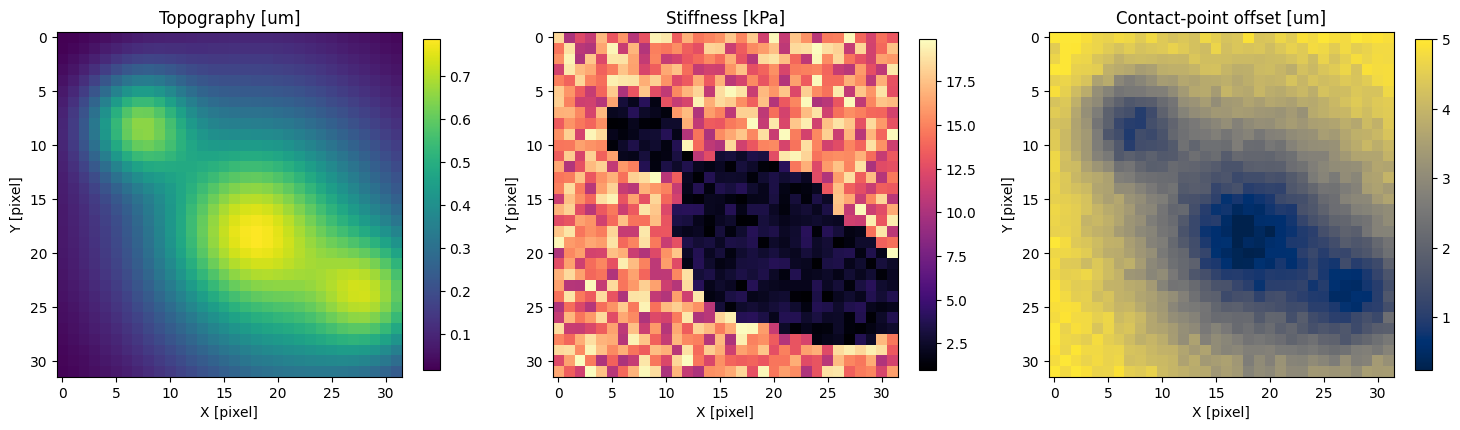

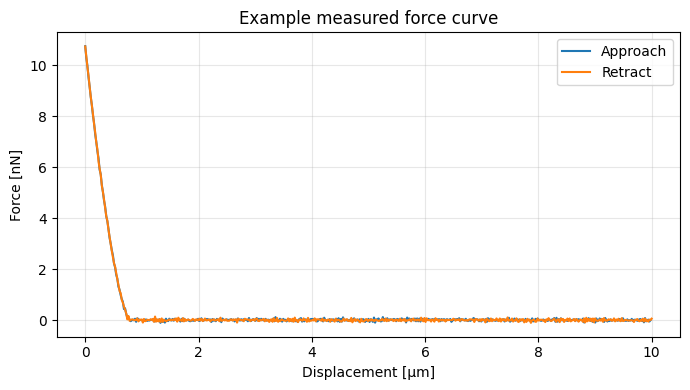

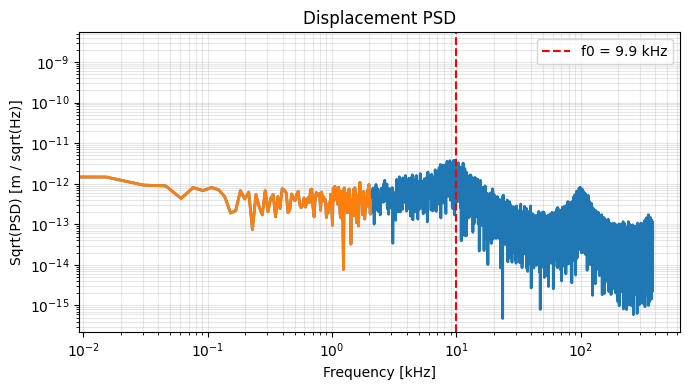

In [353]:
rng = np.random.default_rng(SEED)

cantilever = AFMCantilever(
    k=0.1,
    f0=7e3,
    Q=100.0,
    T=300.0,
)

contact_model = HertzContact(
    R=5e-6,
    nu=0.5,
    alpha=18.0,
)

sample_generator = SampleGenerator(
    substrate_stiffness_range_pa=dataset_config.substrate_stiffness_range_pa,
    feature_stiffness_range_pa=dataset_config.feature_stiffness_range_pa,
    height_range_m=dataset_config.height_range_m,
    contact_point_offset_range_m=dataset_config.contact_point_offset_range_m,
    contact_point_jitter_m=dataset_config.contact_point_jitter_m,
)

simulator = AFMSimulator(
    cantilever=cantilever,
    contact_model=contact_model,
    sample_generator=sample_generator,
    config=simulation_config,
)

print(
    f"Curve shape per sample map = ({simulation_config.ny}, {simulation_config.nx}, {simulator.n_points_total})"
)
print(f"N_points_per_phase = {simulator.n_points_per_phase}")

example_topography_m, example_stiffness_pa, example_contact_point_offset_m = (
    sample_generator.create_topography(
        size=(simulation_config.ny, simulation_config.nx),
        pixel_size_m=simulation_config.pixel_size_m,
        topography_type="gaussian_features",
        rng=rng,
    )
)

example_output = simulator.simulate_force_map(
    stiffness_map_pa=example_stiffness_pa,
    contact_point_offset_map_m=example_contact_point_offset_m,
    include_thermal_noise=simulation_config.include_thermal_noise,
    rng=rng,
)

plot_maps(
    example_topography_m,
    example_stiffness_pa,
    example_contact_point_offset_m,
)

plot_force_curve(
    example_output["displacement_axis_m"],
    example_output["measured_force_n"][
        simulation_config.ny // 2, simulation_config.nx // 2
    ],
    title="Example measured force curve",
)

frequency_hz, spectral_density_m2_per_hz = cantilever.get_noise_psd(
    n_points=simulator.n_points_total,
    sampling_frequency_hz=50000,
    noise_type=simulation_config.noise_type,
    experimental_path=simulation_config.experimental_noise_path,
)
plot_psd(
    frequency_hz,
    spectral_density_m2_per_hz,
    cantilever,
    sampling_frequency=simulation_config.sampling_frequency_hz,
)


## 9. Convert full curves into padded ML inputs

The model will use a padded contact-only representation of the force curves:

- approach branch from first contact to maximum approach
- retract branch from maximum approach until detachment
- padded to a common sequence length

### Important note about normalization

Per-curve normalization might be dangerous


In [354]:
def build_padded_force_inputs(
    measured_force_curves_nN,
    contact_indices,
):
    """Create padded contact-only force curves for machine learning.

    Parameters
    ----------
    measured_force_curves_nN : ndarray
        Force curves with shape `(n_samples, ny, nx, n_total)` in nN.
    contact_indices : ndarray
        Integer contact indices with shape `(n_samples, ny, nx)`.

    Returns
    -------
    dict
        Raw padded force channel, valid mask, phase channel, and valid lengths.
    """
    n_samples, ny, nx, n_points_total = measured_force_curves_nN.shape
    n_points_per_phase = n_points_total // 2

    raw_padded_force_nN = np.zeros_like(measured_force_curves_nN, dtype=np.float32)
    valid_mask = np.zeros_like(measured_force_curves_nN, dtype=np.float32)
    phase_channel = np.zeros_like(measured_force_curves_nN, dtype=np.float32)
    valid_lengths = np.zeros((n_samples, ny, nx), dtype=np.int32)

    for sample_index in range(n_samples):
        for row_index in range(ny):
            for col_index in range(nx):
                start_index = int(contact_indices[sample_index, row_index, col_index])
                approach_curve = measured_force_curves_nN[
                    sample_index, row_index, col_index, :n_points_per_phase
                ]
                retract_curve = measured_force_curves_nN[
                    sample_index, row_index, col_index, n_points_per_phase:
                ]
                approach_segment = approach_curve[start_index:]
                retract_length = n_points_per_phase - start_index
                retract_segment = retract_curve[:retract_length]
                merged_curve = np.concatenate([approach_segment, retract_segment])
                merged_length = merged_curve.shape[0]

                raw_padded_force_nN[
                    sample_index, row_index, col_index, :merged_length
                ] = merged_curve
                valid_mask[sample_index, row_index, col_index, :merged_length] = 1.0
                phase_channel[
                    sample_index, row_index, col_index, : approach_segment.shape[0]
                ] = -1.0
                phase_channel[
                    sample_index,
                    row_index,
                    col_index,
                    approach_segment.shape[0] : merged_length,
                ] = 1.0
                valid_lengths[sample_index, row_index, col_index] = merged_length

    return {
        "raw_padded_force_nN": raw_padded_force_nN,
        "valid_mask": valid_mask,
        "phase_channel": phase_channel,
        "valid_lengths": valid_lengths,
    }


def compute_force_normalization(
    raw_padded_force_nN,
    valid_mask,
):
    """Compute global normalization statistics from valid training points only."""
    valid_values = raw_padded_force_nN[valid_mask > 0.5]
    force_mean_nN = float(valid_values.mean())
    force_std_nN = float(valid_values.std() + 1e-6)
    return {
        "force_mean_nN": force_mean_nN,
        "force_std_nN": force_std_nN,
    }


def normalize_force_channel(
    raw_padded_force_nN,
    valid_mask,
    normalization_stats,
):
    """Normalize the force channel with global training-set statistics."""
    normalized_force = (
        raw_padded_force_nN - normalization_stats["force_mean_nN"]
    ) / normalization_stats["force_std_nN"]
    normalized_force *= valid_mask
    return normalized_force.astype(np.float32)


def flatten_sample_axes(
    input_tensor,
    stiffness_maps_kpa,
    contact_point_offset_maps_nm,
):
    """Flatten `(n_samples, ny, nx, ...)` arrays into a curve-wise dataset."""
    n_samples, ny, nx, n_channels, n_sequence = input_tensor.shape
    sample_index_map = np.repeat(np.arange(n_samples)[:, None, None], ny, axis=1)
    sample_index_map = np.repeat(sample_index_map, nx, axis=2)
    row_index_map = np.repeat(np.arange(ny)[None, :, None], n_samples, axis=0)
    row_index_map = np.repeat(row_index_map, nx, axis=2)
    col_index_map = np.repeat(np.arange(nx)[None, None, :], n_samples, axis=0)
    col_index_map = np.repeat(col_index_map, ny, axis=1)

    return {
        "curve_inputs": input_tensor.reshape(-1, n_channels, n_sequence).astype(
            np.float32
        ),
        "stiffness_targets_kpa": stiffness_maps_kpa.reshape(-1).astype(np.float32),
        "contact_point_targets_nm": contact_point_offset_maps_nm.reshape(-1).astype(
            np.float32
        ),
        "sample_index": sample_index_map.reshape(-1).astype(np.int32),
        "row_index": row_index_map.reshape(-1).astype(np.int32),
        "col_index": col_index_map.reshape(-1).astype(np.int32),
    }


## 10. Generate train / validation / test sample sets

The split is done at the **sample-map level**, not the individual-curve level, to avoid train/test leakage between neighboring pixels from the same synthetic sample.


In [355]:
def generate_sample_collection(
    n_samples,
    simulator: AFMSimulator,
    sample_generator: SampleGenerator,
    dataset_config: DatasetConfig,
    seed,
):
    """Generate a collection of synthetic AFM sample maps and force curves."""
    rng = np.random.default_rng(seed)
    ny = simulator.config.ny
    nx = simulator.config.nx
    n_points_total = simulator.n_points_total

    topography_maps_nm = np.zeros((n_samples, ny, nx), dtype=np.float32)
    stiffness_maps_kpa = np.zeros((n_samples, ny, nx), dtype=np.float32)
    contact_point_offset_maps_nm = np.zeros((n_samples, ny, nx), dtype=np.float32)
    measured_force_curves_nN = np.zeros(
        (n_samples, ny, nx, n_points_total), dtype=np.float32
    )
    contact_indices = np.zeros((n_samples, ny, nx), dtype=np.int32)

    for sample_index in range(n_samples):
        topography_type = "gaussian_features" #rng.choice(dataset_config.topography_types)
        topography_m, stiffness_map_pa, contact_point_offset_map_m = (
            sample_generator.create_topography(
                size=(ny, nx),
                pixel_size_m=simulator.config.pixel_size_m,
                topography_type=topography_type,
                rng=rng,
            )
        )
        output = simulator.simulate_force_map(
            stiffness_map_pa=stiffness_map_pa,
            contact_point_offset_map_m=contact_point_offset_map_m,
            include_thermal_noise=simulator.config.include_thermal_noise,
            noise_type=simulator.config.noise_type,
            experimental_path=simulator.config.experimental_noise_path,
            rng=rng,
        )

        topography_maps_nm[sample_index] = topography_m * 1e9
        stiffness_maps_kpa[sample_index] = stiffness_map_pa / 1e3
        contact_point_offset_maps_nm[sample_index] = contact_point_offset_map_m * 1e9
        measured_force_curves_nN[sample_index] = output["measured_force_n"] * 1e9
        contact_indices[sample_index] = output["contact_indices"]

    return {
        "topography_maps_nm": topography_maps_nm,
        "stiffness_maps_kpa": stiffness_maps_kpa,
        "contact_point_offset_maps_nm": contact_point_offset_maps_nm,
        "measured_force_curves_nN": measured_force_curves_nN,
        "contact_indices": contact_indices,
        "displacement_axis_um": simulator.displacement_axis_m * 1e6,
    }


train_collection = generate_sample_collection(
    n_samples=dataset_config.n_train_samples,
    simulator=simulator,
    sample_generator=sample_generator,
    dataset_config=dataset_config,
    seed=SEED + 10,
)
val_collection = generate_sample_collection(
    n_samples=dataset_config.n_val_samples,
    simulator=simulator,
    sample_generator=sample_generator,
    dataset_config=dataset_config,
    seed=SEED + 20,
)
test_collection = generate_sample_collection(
    n_samples=dataset_config.n_test_samples,
    simulator=simulator,
    sample_generator=sample_generator,
    dataset_config=dataset_config,
    seed=SEED + 30,
)

train_padded = build_padded_force_inputs(
    measured_force_curves_nN=train_collection["measured_force_curves_nN"],
    contact_indices=train_collection["contact_indices"],
)
val_padded = build_padded_force_inputs(
    measured_force_curves_nN=val_collection["measured_force_curves_nN"],
    contact_indices=val_collection["contact_indices"],
)
test_padded = build_padded_force_inputs(
    measured_force_curves_nN=test_collection["measured_force_curves_nN"],
    contact_indices=test_collection["contact_indices"],
)

normalization_stats = compute_force_normalization(
    raw_padded_force_nN=train_padded["raw_padded_force_nN"],
    valid_mask=train_padded["valid_mask"],
)

train_input_tensor = np.stack(
    [
        normalize_force_channel(
            train_padded["raw_padded_force_nN"],
            train_padded["valid_mask"],
            normalization_stats,
        ),
        train_padded["valid_mask"],
        train_padded["phase_channel"],
    ],
    axis=3,
)
val_input_tensor = np.stack(
    [
        normalize_force_channel(
            val_padded["raw_padded_force_nN"],
            val_padded["valid_mask"],
            normalization_stats,
        ),
        val_padded["valid_mask"],
        val_padded["phase_channel"],
    ],
    axis=3,
)
test_input_tensor = np.stack(
    [
        normalize_force_channel(
            test_padded["raw_padded_force_nN"],
            test_padded["valid_mask"],
            normalization_stats,
        ),
        test_padded["valid_mask"],
        test_padded["phase_channel"],
    ],
    axis=3,
)

train_flat = flatten_sample_axes(
    input_tensor=train_input_tensor,
    stiffness_maps_kpa=train_collection["stiffness_maps_kpa"],
    contact_point_offset_maps_nm=train_collection["contact_point_offset_maps_nm"],
)
val_flat = flatten_sample_axes(
    input_tensor=val_input_tensor,
    stiffness_maps_kpa=val_collection["stiffness_maps_kpa"],
    contact_point_offset_maps_nm=val_collection["contact_point_offset_maps_nm"],
)
test_flat = flatten_sample_axes(
    input_tensor=test_input_tensor,
    stiffness_maps_kpa=test_collection["stiffness_maps_kpa"],
    contact_point_offset_maps_nm=test_collection["contact_point_offset_maps_nm"],
)

print("Train curves:", train_flat["curve_inputs"].shape)
print("Validation curves:", val_flat["curve_inputs"].shape)
print("Test curves:", test_flat["curve_inputs"].shape)
print("Force normalization:", normalization_stats)

Train curves: (18432, 3, 1024)
Validation curves: (4096, 3, 1024)
Test curves: (3072, 3, 1024)
Force normalization: {'force_mean_nN': -9.320778190158308e-06, 'force_std_nN': 0.040696945041418076}



## 11. Dataset wrappers


In [356]:
class AFMCurveDataset(Dataset):
    """Curve-wise dataset for AFM regression."""

    curve_inputs: torch.Tensor
    stiffness_targets_kpa: torch.Tensor
    contact_point_targets_nm: torch.Tensor

    def __init__(
        self,
        curve_inputs,
        stiffness_targets_kpa,
        contact_point_targets_nm,
        predict_contact_point=False,
    ):
        self.curve_inputs = torch.tensor(curve_inputs, dtype=torch.float32)
        self.stiffness_targets_kpa = torch.tensor(
            stiffness_targets_kpa[:, None], dtype=torch.float32
        )
        self.contact_point_targets_nm = torch.tensor(
            contact_point_targets_nm[:, None], dtype=torch.float32
        )
        self.predict_contact_point = predict_contact_point

    def __len__(self):
        return int(self.curve_inputs.shape[0])

    def __getitem__(self, index):
        x = self.curve_inputs[index]
        if self.predict_contact_point:
            target = torch.cat(
                [
                    self.stiffness_targets_kpa[index],
                    self.contact_point_targets_nm[index],
                ],
                dim=0,
            )
        else:
            target = self.stiffness_targets_kpa[index]
        return x, target


train_dataset = AFMCurveDataset(
    curve_inputs=train_flat["curve_inputs"],
    stiffness_targets_kpa=train_flat["stiffness_targets_kpa"],
    contact_point_targets_nm=train_flat["contact_point_targets_nm"],
    predict_contact_point=model_config.predict_contact_point,
)
val_dataset = AFMCurveDataset(
    curve_inputs=val_flat["curve_inputs"],
    stiffness_targets_kpa=val_flat["stiffness_targets_kpa"],
    contact_point_targets_nm=val_flat["contact_point_targets_nm"],
    predict_contact_point=model_config.predict_contact_point,
)
test_dataset = AFMCurveDataset(
    curve_inputs=test_flat["curve_inputs"],
    stiffness_targets_kpa=test_flat["stiffness_targets_kpa"],
    contact_point_targets_nm=test_flat["contact_point_targets_nm"],
    predict_contact_point=model_config.predict_contact_point,
)

train_dataloader = DataLoader(
    train_dataset,
    batch_size=model_config.batch_size,
    shuffle=True,
    num_workers=model_config.num_workers,
)
val_dataloader = DataLoader(
    val_dataset,
    batch_size=model_config.batch_size,
    shuffle=False,
    num_workers=model_config.num_workers,
)
test_dataloader = DataLoader(
    test_dataset,
    batch_size=model_config.batch_size,
    shuffle=False,
    num_workers=model_config.num_workers,
)


## 12. 1D CNN model and loss functions

The backbone is a standard 1D CNN.




In [357]:
class SafeMAPELoss(nn.Module):
    """Numerically safe mean absolute percentage error loss."""

    epsilon: float

    def __init__(self, epsilon=1e-6):
        super().__init__()
        self.epsilon = epsilon

    def forward(self, prediction, target):
        denominator = target.abs().clamp_min(self.epsilon)
        return torch.mean(torch.abs(prediction - target) / denominator)


class AFMCurveCNN(nn.Module):
    """1D CNN for AFM force-curve regression.

    Parameters
    ----------
    in_channels : int, optional
        Number of input channels.
    hidden_channels : tuple of int, optional
        Number of channels in each convolutional stage.
    predict_contact_point : bool, optional
        Whether to add a second regression head for contact-point offset.

    Input
    -----
    x : torch.Tensor
        Tensor of shape `(batch, channels, sequence_length)`.

    Output
    ------
    torch.Tensor or tuple of torch.Tensor
        If `predict_contact_point=False`, returns stiffness in kPa with shape
        `(batch, 1)`. Otherwise returns `(stiffness_kPa, contact_point_nm)`.

    Evaluation
    ----------
    `x -> backbone -> global average pooling -> regression head(s)`
    """

    backbone: nn.Module
    pool: nn.Module
    stiffness_head: nn.Module
    contact_point_head: Optional[nn.Module]
    predict_contact_point: bool

    def __init__(
        self,
        in_channels=3,
        hidden_channels=(16, 32, 64),
        predict_contact_point=False,
    ):
        super().__init__()
        self.predict_contact_point = predict_contact_point
        self.backbone = nn.Sequential(
            nn.Conv1d(in_channels, hidden_channels[0], kernel_size=7, padding=3),
            nn.BatchNorm1d(hidden_channels[0]),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(hidden_channels[0], hidden_channels[1], kernel_size=5, padding=2),
            nn.BatchNorm1d(hidden_channels[1]),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(hidden_channels[1], hidden_channels[2], kernel_size=5, padding=2),
            nn.BatchNorm1d(hidden_channels[2]),
            nn.ReLU(),
        )
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.stiffness_head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(hidden_channels[2], 64),
            nn.ReLU(),
            nn.Linear(64, 1),
            nn.Softplus(),
        )
        self.contact_point_head = None
        if self.predict_contact_point:
            self.contact_point_head = nn.Sequential(
                nn.Flatten(),
                nn.Linear(hidden_channels[2], 64),
                nn.ReLU(),
                nn.Linear(64, 1),
                nn.Softplus(),
            )

    def forward(self, x: torch.Tensor):
        features = self.backbone(x)
        pooled_features = self.pool(features)
        stiffness_kpa = self.stiffness_head(pooled_features)
        if not self.predict_contact_point:
            return stiffness_kpa
        if self.contact_point_head is None:
            raise RuntimeError(
                "`predict_contact_point=True` but no contact-point head is defined."
            )
        contact_point_nm = self.contact_point_head(pooled_features)
        return stiffness_kpa, contact_point_nm


## 13. Deeplay application


In [358]:
try:
    import deeplay as dl
    from deeplay.applications import Application
    from deeplay.external import Adam
    import torchmetrics as tm

    DEEPLAY_AVAILABLE = True
    print("Deeplay is available.")
except Exception as error:
    dl = None
    Application = nn.Module
    Adam = torch.optim.Adam
    tm = None
    DEEPLAY_AVAILABLE = False
    print(
        "Deeplay is not installed in this environment. The fallback PyTorch trainer will be used."
    )
    print(f"Import error: {error}")


if DEEPLAY_AVAILABLE:

    class AFMStiffnessRegressor(Application):
        """Deeplay application for AFM stiffness regression.

        Parameters
        ----------
        model : nn.Module
            Backbone model used for the regression task.
        learning_rate : float, optional
            Optimizer learning rate.
        metrics : list, optional
            Additional metrics. If None, MAE and MAPE are used.

        Input
        -----
        x : torch.Tensor
            Tensor of shape `(batch, channels, sequence_length)`.

        Output
        ------
        torch.Tensor
            Stiffness prediction in kPa with shape `(batch, 1)`.

        Evaluation
        ----------
        `y_hat = model(x)`
        """

        model: nn.Module

        def __init__(
            self,
            model: nn.Module,
            learning_rate: float = 1e-3,
            metrics: Optional[List[nn.Module]] = None,
            **kwargs,
        ) -> None:
            if metrics is None:
                metrics = [
                    tm.MeanAbsoluteError(),
                    tm.MeanAbsolutePercentageError(),
                ]
            super().__init__(
                loss=SafeMAPELoss(),
                optimizer=Adam(lr=learning_rate),
                metrics=metrics,
                **kwargs,
            )
            self.model = model

        def forward(self, x: torch.Tensor) -> torch.Tensor:
            """Run the forward pass of the regression backbone."""
            return self.model(x)

        def compute_loss(self, y_hat: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
            """Compute the regression loss."""
            return self.loss(y_hat, y.float())

Deeplay is available.



## 14. Training helpers


In [359]:
def evaluate_mape(
    model,
    dataloader,
    device,
):
    """Evaluate MAPE on a dataloader."""
    criterion = SafeMAPELoss()
    model.eval()
    running_loss = 0.0
    n_samples = 0
    with torch.no_grad():
        for batch_x, batch_y in dataloader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)
            prediction = model(batch_x)
            if isinstance(prediction, tuple):
                prediction = prediction[0]
            loss = criterion(prediction, batch_y)
            running_loss += float(loss.item()) * batch_x.shape[0]
            n_samples += int(batch_x.shape[0])
    return running_loss / max(n_samples, 1)


def train_with_pytorch_fallback(
    model,
    train_dataloader,
    val_dataloader,
    learning_rate,
    max_epochs,
    device,
):
    """Train the CNN with a plain PyTorch loop when Deeplay is unavailable."""
    criterion = SafeMAPELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    history = {"train_mape": [], "val_mape": []}

    model.to(device)
    for epoch_index in range(max_epochs):
        model.train()
        running_loss = 0.0
        n_samples = 0
        for batch_x, batch_y in train_dataloader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)
            optimizer.zero_grad()
            prediction = model(batch_x)
            if isinstance(prediction, tuple):
                prediction = prediction[0]
            loss = criterion(prediction, batch_y)
            loss.backward()
            optimizer.step()
            running_loss += float(loss.item()) * batch_x.shape[0]
            n_samples += int(batch_x.shape[0])

        train_mape = running_loss / max(n_samples, 1)
        val_mape = evaluate_mape(model, val_dataloader, device)
        history["train_mape"].append(train_mape)
        history["val_mape"].append(val_mape)
        print(
            f"Epoch {epoch_index + 1:02d}/{max_epochs:02d} | "
            f"train MAPE = {train_mape:.4f} | val MAPE = {val_mape:.4f}"
        )

    return history


def predict_curvewise(
    model,
    curve_inputs,
    batch_size=256,
    device=None,
):
    """Run curve-wise prediction and return a flat numpy array."""
    device = torch.device("cpu") if device is None else device
    model.eval()
    predictions: List[Array] = []
    with torch.no_grad():
        for start_index in range(0, curve_inputs.shape[0], batch_size):
            end_index = min(start_index + batch_size, curve_inputs.shape[0])
            batch_x = torch.tensor(
                curve_inputs[start_index:end_index], dtype=torch.float32, device=device
            )
            batch_prediction = model(batch_x)
            if isinstance(batch_prediction, tuple):
                batch_prediction = batch_prediction[0]
            predictions.append(batch_prediction.detach().cpu().numpy())
    return np.concatenate(predictions, axis=0).reshape(-1)


## 15. Train the regressor

The cell below automatically uses Deeplay when it is installed.


In [360]:
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = "cpu"
print("Training device:", device)

model = AFMCurveCNN(
    in_channels=train_flat["curve_inputs"].shape[1],
    hidden_channels=(16, 32, 64),
    predict_contact_point=model_config.predict_contact_point,
)

history = None
trained_model = model

if DEEPLAY_AVAILABLE and model_config.use_deeplay:
    application = AFMStiffnessRegressor(
        model=model,
        learning_rate=model_config.learning_rate,
    ).build()
    trainer = dl.Trainer(
        accelerator="cpu",
        # devices="cpu",
        max_epochs=model_config.max_epochs,
        enable_checkpointing=False,
        logger=False,
        enable_model_summary=False,
    )
    trainer.fit(
        application,
        train_dataloaders=train_dataloader,
        val_dataloaders=val_dataloader,
    )
    trained_model = application.model.to(device)
else:
    history = train_with_pytorch_fallback(
        model=model,
        train_dataloader=train_dataloader,
        val_dataloader=val_dataloader,
        learning_rate=model_config.learning_rate,
        max_epochs=model_config.max_epochs,
        device=device,
    )
    trained_model = model.to(device)

Training device: cpu


/home/demirpehlivan/envnaz/lib/python3.10/site-packages/lightning/pytorch/trainer/setup.py:175: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
/home/demirpehlivan/envnaz/lib/python3.10/site-packages/torch/cuda/__init__.py:435: UserWarning: 
    Found GPU0 NVIDIA GeForce GTX 1050 Ti which is of cuda capability 6.1.
    Minimum and Maximum cuda capability supported by this version of PyTorch is
    (7.0) - (12.0)
    
  queued_call()
/home/demirpehlivan/envnaz/lib/python3.10/site-packages/torch/cuda/__init__.py:435: UserWarning: 
    Please install PyTorch with a following CUDA
    configurations:  12.6 following instructions at
    https://pytorch.org/get-started/locally/
    
  queued_call()
/home/demirpehlivan/envnaz/lib/python3.10/site-packages/torch/cuda/__init__.py:435: UserWarning: 
NVIDIA GeForce GTX 1050 Ti with CUDA capability sm_61 is not compatible with the current PyTorch installation.
The current PyTorch install supports CUDA capabilities 

Sanity Checking: |                                        | 0/? [00:00<?, ?it/s]

/home/demirpehlivan/envnaz/lib/python3.10/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/home/demirpehlivan/envnaz/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


TypeError: unsupported operand type(s) for -: 'tuple' and 'Tensor'


## 16. Evaluate on the test set and reconstruct 2D stiffness maps


In [ ]:
if history is not None:
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(history["train_mape"], label="Train MAPE")
    ax.plot(history["val_mape"], label="Validation MAPE")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("MAPE")
    ax.set_title("Fallback training history")
    ax.grid(alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()


test_predictions_kpa = predict_curvewise(
    model=trained_model,
    curve_inputs=test_flat["curve_inputs"],
    batch_size=model_config.batch_size,
    device=device,
)

predicted_stiffness_maps_kpa = test_predictions_kpa.reshape(
    test_collection["stiffness_maps_kpa"].shape
)

sample_to_display = 0
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
image_true = axes[0].imshow(
    test_collection["stiffness_maps_kpa"][sample_to_display], cmap="magma"
)
axes[0].set_title("True stiffness map [kPa]")
axes[0].set_xlabel("X [pixel]")
axes[0].set_ylabel("Y [pixel]")
plt.colorbar(image_true, ax=axes[0], shrink=0.8)

image_pred = axes[1].imshow(
    predicted_stiffness_maps_kpa[sample_to_display], cmap="magma"
)
axes[1].set_title("Predicted stiffness map [kPa]")
axes[1].set_xlabel("X [pixel]")
axes[1].set_ylabel("Y [pixel]")
plt.colorbar(image_pred, ax=axes[1], shrink=0.8)

plt.tight_layout()
plt.show()

absolute_percentage_error = np.abs(
    predicted_stiffness_maps_kpa - test_collection["stiffness_maps_kpa"]
) / np.clip(test_collection["stiffness_maps_kpa"], 1e-6, None)
print("Mean test MAPE:", float(np.mean(absolute_percentage_error)))


## 18. Clickable stiffness-map viewer

The function below uses Plotly `FigureWidget` when available.



In [ ]:
try:
    import ipywidgets as widgets
    import plotly.graph_objects as go

    PLOTLY_WIDGETS_AVAILABLE = True
except Exception as error:
    widgets = None
    go = None
    PLOTLY_WIDGETS_AVAILABLE = False
    print("Interactive Plotly widgets are unavailable in this environment.")
    print(f"Import error: {error}")


def show_curve_for_pixel(
    sample_index,
    row_index,
    col_index,
):
    """Static helper for environments without interactive widgets."""
    displacement_axis_um = test_collection["displacement_axis_um"]
    full_curve_nN = test_collection["measured_force_curves_nN"][
        sample_index, row_index, col_index
    ]
    n_points_half = displacement_axis_um.shape[0] // 2
    true_value_kpa = test_collection["stiffness_maps_kpa"][
        sample_index, row_index, col_index
    ]
    predicted_value_kpa = predicted_stiffness_maps_kpa[
        sample_index, row_index, col_index
    ]
    cp_value_nm = test_collection["contact_point_offset_maps_nm"][
        sample_index, row_index, col_index
    ]

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(
        displacement_axis_um[:n_points_half],
        full_curve_nN[:n_points_half],
        label="Approach",
    )
    ax.plot(
        displacement_axis_um[n_points_half:],
        full_curve_nN[n_points_half:],
        label="Retract",
    )
    ax.set_xlabel("Displacement [µm]")
    ax.set_ylabel("Measured force [nN]")
    ax.set_title(
        f"Sample {sample_index}, pixel ({row_index}, {col_index}) | "
        f"true = {true_value_kpa:.2f} kPa | pred = {predicted_value_kpa:.2f} kPa | "
        f"cp = {cp_value_nm:.1f} nm"
    )
    ax.grid(alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()


if PLOTLY_WIDGETS_AVAILABLE:

    def display_clickable_stiffness_map(sample_index=0):
        """Display a clickable stiffness map linked to the underlying curve."""
        predicted_map_kpa = predicted_stiffness_maps_kpa[sample_index]
        true_map_kpa = test_collection["stiffness_maps_kpa"][sample_index]
        cp_map_nm = test_collection["contact_point_offset_maps_nm"][sample_index]
        full_curves_nN = test_collection["measured_force_curves_nN"][sample_index]
        displacement_axis_um = test_collection["displacement_axis_um"]
        n_points_half = displacement_axis_um.shape[0] // 2

        heatmap_figure = go.FigureWidget(
            data=[
                go.Heatmap(
                    z=predicted_map_kpa,
                    colorscale="Viridis",
                    colorbar={"title": "Predicted stiffness [kPa]"},
                )
            ]
        )
        heatmap_figure.update_layout(
            title=f"Clickable predicted stiffness map | sample {sample_index}",
            xaxis_title="X [pixel]",
            yaxis_title="Y [pixel]",
            width=550,
            height=450,
        )

        curve_figure = go.FigureWidget(
            data=[
                go.Scatter(name="Approach", mode="lines"),
                go.Scatter(name="Retract", mode="lines"),
            ]
        )
        curve_figure.update_layout(
            title="Click a pixel in the map",
            xaxis_title="Displacement [µm]",
            yaxis_title="Measured force [nN]",
            width=650,
            height=450,
        )

        def handle_click(trace, points, selector):
            if len(points.point_inds) == 0:
                return
            flat_index = int(points.point_inds[0])
            row_index = flat_index // predicted_map_kpa.shape[1]
            col_index = flat_index % predicted_map_kpa.shape[1]
            full_curve_nN = full_curves_nN[row_index, col_index]
            true_value_kpa = true_map_kpa[row_index, col_index]
            predicted_value_kpa = predicted_map_kpa[row_index, col_index]
            cp_value_nm = cp_map_nm[row_index, col_index]

            with curve_figure.batch_update():
                curve_figure.data[0].x = displacement_axis_um[:n_points_half]
                curve_figure.data[0].y = full_curve_nN[:n_points_half]
                curve_figure.data[1].x = displacement_axis_um[n_points_half:]
                curve_figure.data[1].y = full_curve_nN[n_points_half:]
                curve_figure.layout.title = (
                    f"Pixel ({row_index}, {col_index}) | "
                    f"true = {true_value_kpa:.2f} kPa | pred = {predicted_value_kpa:.2f} kPa | "
                    f"cp = {cp_value_nm:.1f} nm"
                )

        heatmap_figure.data[0].on_click(handle_click)
        display(widgets.HBox([heatmap_figure, curve_figure]))

    display_clickable_stiffness_map(sample_index=sample_to_display)
else:
    print(
        "Interactive widgets are not available. Use `show_curve_for_pixel(sample, row, col)` instead."
    )
    show_curve_for_pixel(sample_index=sample_to_display, row_index=0, col_index=0)

In [ ]:
from google.colab import output

output.enable_custom_widget_manager()

Support for third party widgets will remain active for the duration of the session. To disable support: